<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [2]:
!pip install pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [ ]:
# !wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [ ]:
import pandas as pd
import matpl

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Load the data


In [3]:
df = pd.read_csv("survey_data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.




In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load and connect
df = pd.read_csv('survey_data.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('survey', conn, index=False)

# SQL Query to get the raw points grouped by Age
# (Calculating exact Median in SQL is complex, so we group here and median in Pandas)
query = "SELECT Age, JobSatPoints_6, JobSatPoints_7 FROM survey"
df_sq = pd.read_sql(query, conn)
df_sq

,Age,JobSatPoints_6,JobSatPoints_7
0,Under 18 years old,NaN,NaN
1,35-44 years old,0.0,0.0
2,45-54 years old,NaN,NaN
3,18-24 years old,NaN,NaN
4,18-24 years old,NaN,NaN
...,...,...,...
65452,18-24 years old,NaN,NaN
65453,18-24 years old,50.0,50.0
65454,35-44 years old,0.0,60.0
65455,25-34 years old,0.0,0.0


In [10]:
df_median = df_sq.groupby('Age').median()

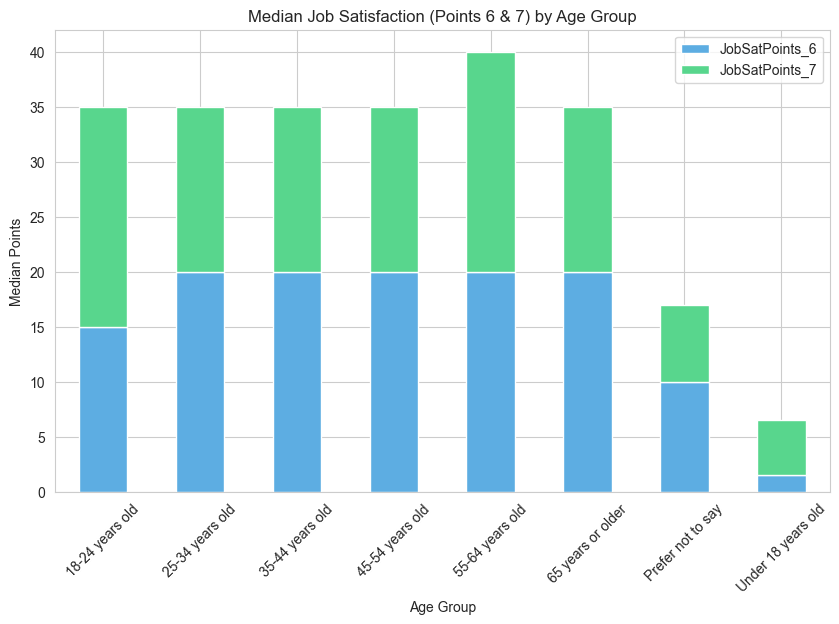

In [11]:
##Write your code here
# Plotting
df_median.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#5dade2', '#58d68d'])

plt.title('Median Job Satisfaction (Points 6 & 7) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Points')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.xticks(rotation=45)
plt.show()



##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


In [8]:
# Load and connect
df = pd.read_csv('survey_data.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('survey', conn, index=False)

# SQL Query to get the raw points grouped by Age
# (Calculating exact Median in SQL is complex, so we group here and median in Pandas)
query = "SELECT Employment, JobSatPoints_6, JobSatPoints_7 FROM survey"
df_sq = pd.read_sql(query, conn)
df_sq

,Employment,JobSatPoints_6,JobSatPoints_7
0,"Employed, full-time",NaN,NaN
1,"Employed, full-time",0.0,0.0
2,"Employed, full-time",NaN,NaN
3,"Student, full-time",NaN,NaN
4,"Student, full-time",NaN,NaN
...,...,...,...
65452,"Student, full-time;Employed, part-time",NaN,NaN
65453,"Employed, full-time;Employed, part-time",50.0,50.0
65454,"Employed, full-time;Independent contractor, fr...",0.0,60.0
65455,"Employed, full-time",0.0,0.0


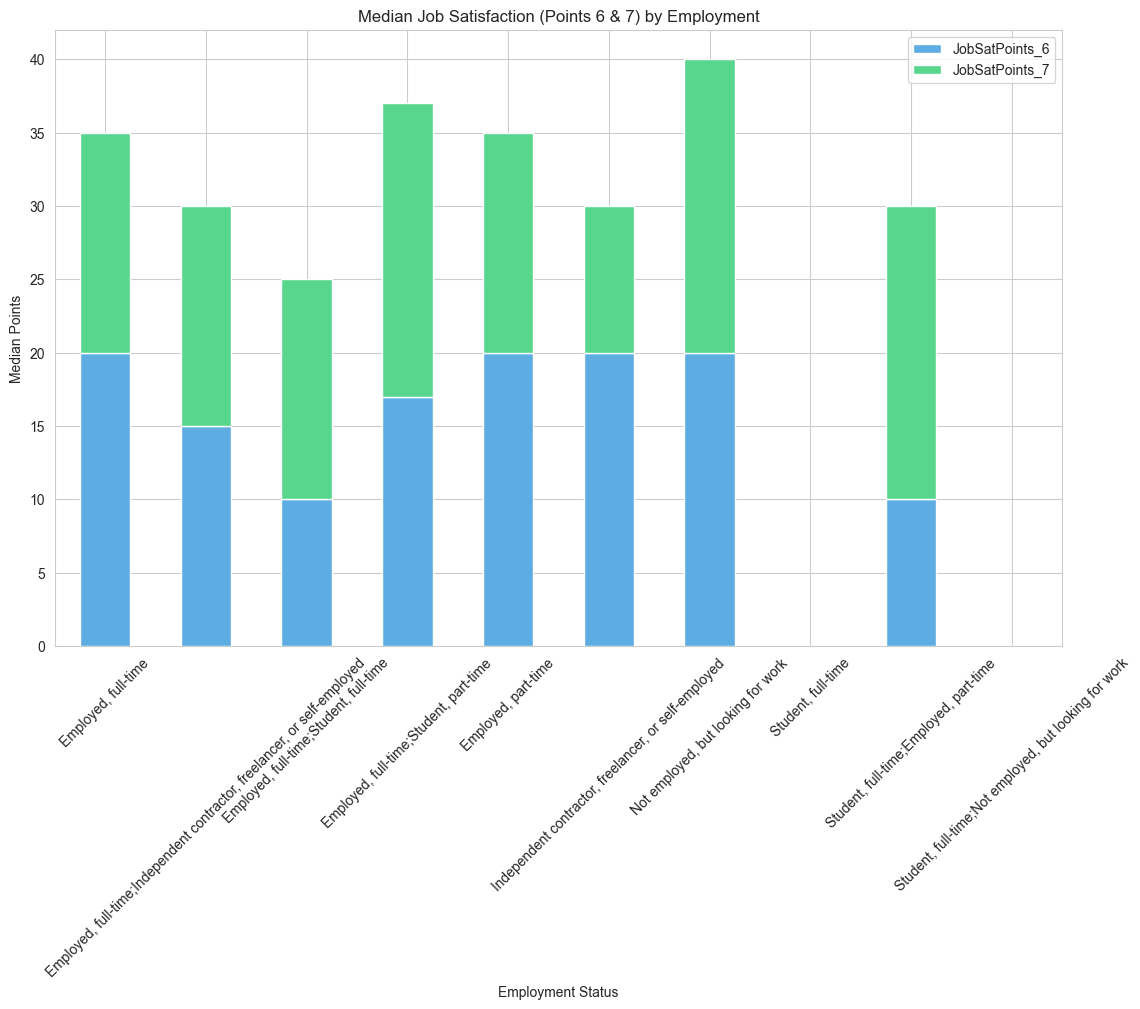

In [25]:
##Write your code here
# df_median = df_sq.groupby('Employment').median().head(10)
# 1. Get the top 10 most common employment types first
top_employment = df_sq['Employment'].value_counts().nlargest(10).index

# 2. Filter your median data to only show those 10
df_median = df_sq[df_sq['Employment'].isin(top_employment)].groupby('Employment').median()

df_median.plot(kind='bar', stacked=True, figsize=(13, 8), color=['#5dade2', '#58d68d'])

plt.title('Median Job Satisfaction (Points 6 & 7) by Employment')
plt.xlabel('Employment Status')
plt.ylabel('Median Points')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


In [13]:
query = "SELECT Age, ConvertedCompYearly, JobSatPoints_6 FROM survey where Age = '25-34 years old'"
df_2534 = pd.read_sql(query, conn).dropna()
# 1. Filter top 1% outliers and scale salary (dividing by 10k makes $70k become 7.0)
upper_limit = df_2534['ConvertedCompYearly'].quantile(0.99)
df_plot = df_2534[df_2534['ConvertedCompYearly'] <= upper_limit].copy()
df_plot['Salary_Scaled'] = df_plot['ConvertedCompYearly'] / 10000

# 2. Plot the first 10 rows as a stacked bar chart
df_plot[['Salary_Scaled', 'JobSatPoints_6']].head(10)


,Salary_Scaled,JobSatPoints_6
116,11.0000,20.0
122,2.9000,0.0
125,6.6592,30.0
127,23.0000,0.0
130,14.6496,30.0
131,6.9814,30.0
134,6.4570,10.0
137,5.4777,25.0
139,3.7297,20.0
140,21.3840,0.0


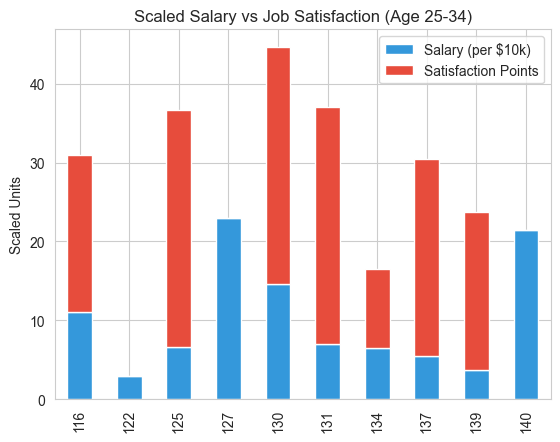

In [12]:
df_plot[['Salary_Scaled', 'JobSatPoints_6']].head(10).plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'])
plt.title('Scaled Salary vs Job Satisfaction (Age 25-34)')
plt.ylabel('Scaled Units')
plt.legend(['Salary (per $10k)', 'Satisfaction Points'])
plt.show()


In [ ]:
##Write your code here

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


In [15]:
query = """
SELECT Age, ConvertedCompYearly, JobSatPoints_6
FROM survey
WHERE ConvertedCompYearly IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_age_comp = pd.read_sql(query, conn)

In [23]:
# Calculate median for each age group
df_grouped = df_age_comp.groupby('Age').median()
print(df_grouped)
# Optional: Sort by Age if the labels are numeric or follow a logical order
df_grouped = df_grouped.sort_index()


                    ConvertedCompYearly  JobSatPoints_6
Age                                                    
18-24 years old                 25735.0            20.0
25-34 years old                 59872.0            20.0
35-44 years old                 85925.0            20.0
45-54 years old                100900.5            20.0
55-64 years old                119189.5            20.0
65 years or older              121668.0            20.0
Prefer not to say              133023.5            15.0
Under 18 years old               8661.0            10.0


In [22]:
df_grouped['Comp_Scaled'] = df_grouped['ConvertedCompYearly'] / 10000


<Axes: xlabel='Age'>

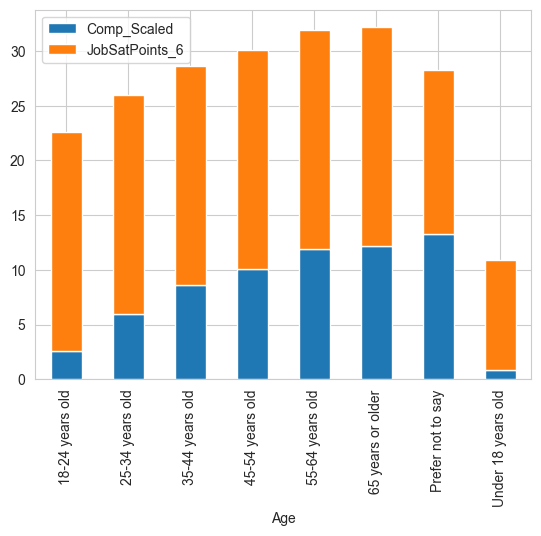

In [25]:
# Plotting Scaled Compensation vs Satisfaction
# 1. Group and calculate median first
df_grouped = df_age_comp.groupby('Age').median()

# 2. Create the scaled column in the NEW grouped dataframe
df_grouped['Comp_Scaled'] = df_grouped['ConvertedCompYearly'] / 10000

# 3. Now plot using the columns that actually exist in df_grouped
df_grouped[['Comp_Scaled', 'JobSatPoints_6']].plot(kind='bar', stacked=True)



### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


In [8]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your main DataFrame

# Explode the 'DatabaseWantToWorkWith' column
df['Database'] = df['DatabaseWantToWorkWith'].str.split(';')
df_expanded = df.explode('Database').dropna(subset=['Database', 'Age'])

# Optional: Clean up whitespace and get top 10 databases to prevent messy charts
df_expanded['Database'] = df_expanded['Database'].str.strip()
top_dbs = df_expanded['Database'].value_counts().head(10).index
print(top_dbs)
df_filtered = df_expanded[df_expanded['Database'].isin(top_dbs)]


Index(['PostgreSQL', 'SQLite', 'MySQL', 'MongoDB', 'Redis',
       'Microsoft SQL Server', 'Elasticsearch', 'MariaDB', 'Dynamodb',
       'Supabase'],
      dtype='str', name='Database')


In [9]:
# Fix: Ensure the index has no duplicates
df_filtered = df_filtered.reset_index(drop=True)
# Create a count table (Age as rows, Databases as columns)
counts = pd.crosstab(df_filtered['Age'], df_filtered['Database'])
counts

Database,Dynamodb,Elasticsearch,MariaDB,Microsoft SQL Server,MongoDB,MySQL,PostgreSQL,Redis,SQLite,Supabase
Age,,,,,,,,,,
18-24 years old,591,1087,1243,1115,3028,3078,5116,2236,3054,985
25-34 years old,1534,2707,1994,2631,4363,4465,9524,4542,4897,1129
35-44 years old,946,1651,1456,2184,2141,2538,5772,2781,3062,471
45-54 years old,312,573,710,1226,773,1125,2201,865,1293,142
55-64 years old,75,148,287,552,234,471,724,176,493,24
65 years or older,13,15,85,105,45,144,108,20,132,9
Prefer not to say,7,15,21,26,26,41,61,21,55,4
Under 18 years old,26,51,154,67,374,411,506,209,508,168


In [10]:
# Divide each row by its total sum
proportions = counts.div(counts.sum(axis=1), axis=0) * 100
proportions

Database,Dynamodb,Elasticsearch,MariaDB,Microsoft SQL Server,MongoDB,MySQL,PostgreSQL,Redis,SQLite,Supabase
Age,,,,,,,,,,
18-24 years old,2.744625,5.048066,5.772535,5.178099,14.062137,14.294339,23.758882,10.384062,14.182882,4.574374
25-34 years old,4.059705,7.164029,5.277087,6.962896,11.546605,11.816546,25.205102,12.020325,12.959826,2.987879
35-44 years old,4.112686,7.177637,6.329884,9.494827,9.307886,11.033823,25.093470,12.090253,13.311886,2.047648
45-54 years old,3.383948,6.214751,7.700651,13.297180,8.383948,12.201735,23.872017,9.381779,14.023861,1.540130
55-64 years old,2.355528,4.648241,9.013819,17.336683,7.349246,14.792714,22.738693,5.527638,15.483668,0.753769
65 years or older,1.923077,2.218935,12.573964,15.532544,6.656805,21.301775,15.976331,2.958580,19.526627,1.331361
Prefer not to say,2.527076,5.415162,7.581227,9.386282,9.386282,14.801444,22.021661,7.581227,19.855596,1.444043
Under 18 years old,1.050930,2.061439,6.224737,2.708165,15.117219,16.612773,20.452708,8.447858,20.533549,6.790622


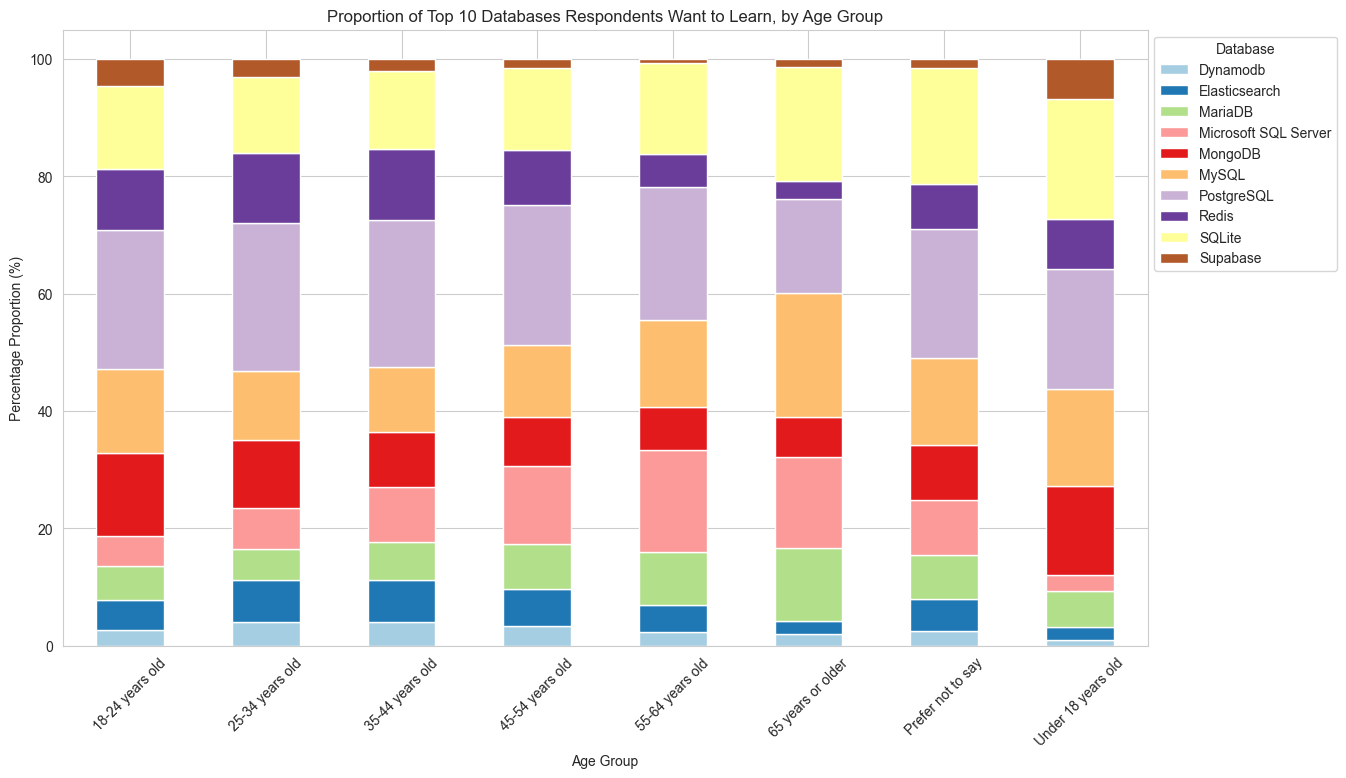

In [11]:
# Plotting
ax = proportions.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='Paired')

plt.title('Proportion of Top 10 Databases Respondents Want to Learn, by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage Proportion (%)')
plt.xticks(rotation=45)
# Move the legend outside the plot area
ax.legend(title='Database', bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.show()


##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [17]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame, adapt column names if needed
df_clean = df[['Employment', 'JobSatPoints_6']].dropna()

# Optional: Clean up whitespace in string columns
df_clean['Employment'] = df_clean['Employment'].str.strip().head(15)
df_clean['Employment']

1        Employed, full-time
10       Employed, full-time
12       Employed, full-time
15       Employed, full-time
18       Employed, full-time
                ...         
65447                    NaN
65449                    NaN
65453                    NaN
65454                    NaN
65455                    NaN
Name: Employment, Length: 29456, dtype: str

In [18]:
# Create a count table (Satisfaction as rows, Employment Type as columns)
counts = pd.crosstab(df_clean['JobSatPoints_6'], df_clean['Employment'])
counts

Employment,"Employed, full-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Student, part-time"
JobSatPoints_6,,,
0.0,3,0,1
10.0,2,0,0
15.0,1,0,0
20.0,1,0,0
25.0,2,0,0
30.0,2,0,0
50.0,0,1,0
60.0,1,0,0
100.0,1,0,0


In [19]:
# Divide each row by its total sum
proportions = counts.div(counts.sum(axis=1), axis=0) * 100
proportions

Employment,"Employed, full-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Student, part-time"
JobSatPoints_6,,,
0.0,75.0,0.0,25.0
10.0,100.0,0.0,0.0
15.0,100.0,0.0,0.0
20.0,100.0,0.0,0.0
25.0,100.0,0.0,0.0
30.0,100.0,0.0,0.0
50.0,0.0,100.0,0.0
60.0,100.0,0.0,0.0
100.0,100.0,0.0,0.0


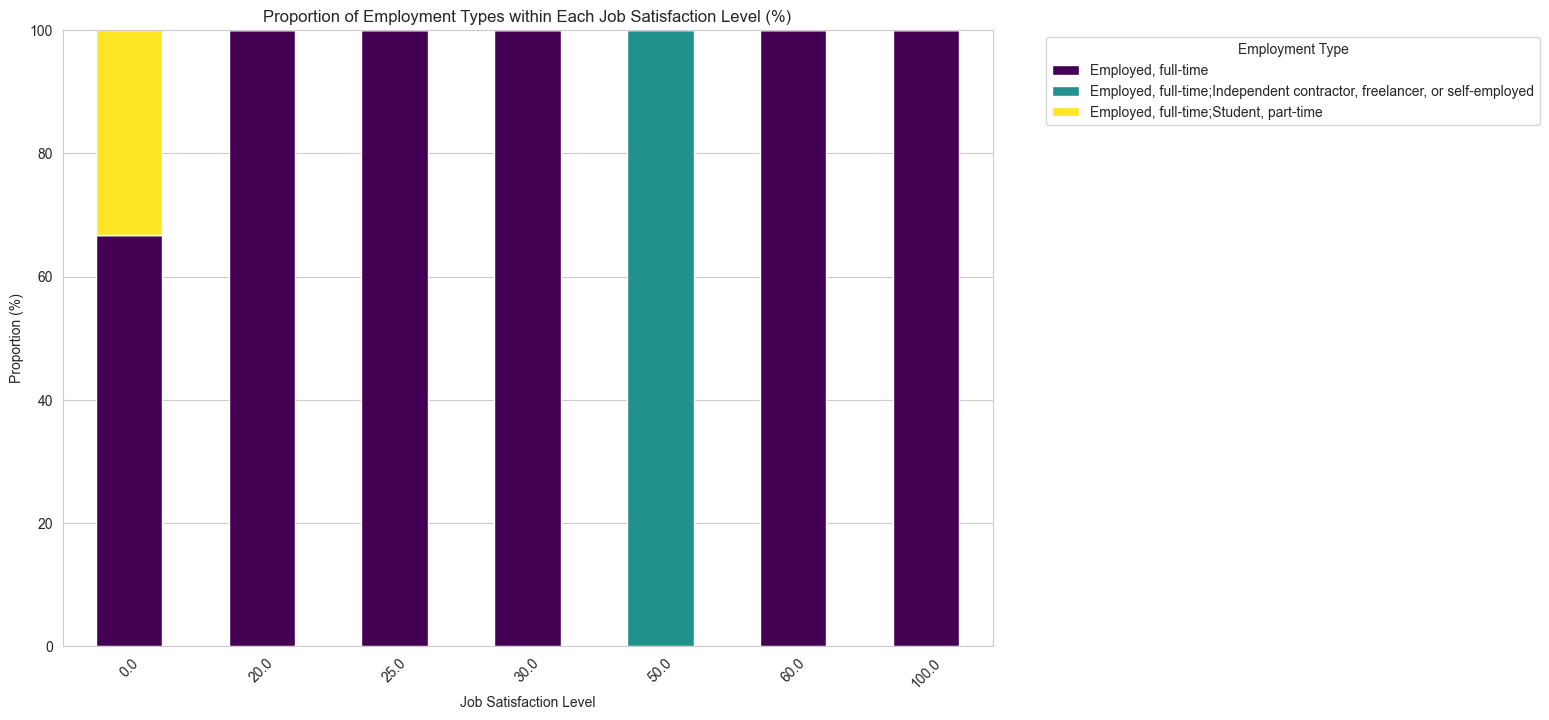

In [46]:
# Plotting
ax = proportions.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Proportion of Employment Types within Each Job Satisfaction Level (%)')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45)

# Move the legend outside the plot area
ax.legend(title='Employment Type', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()


### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


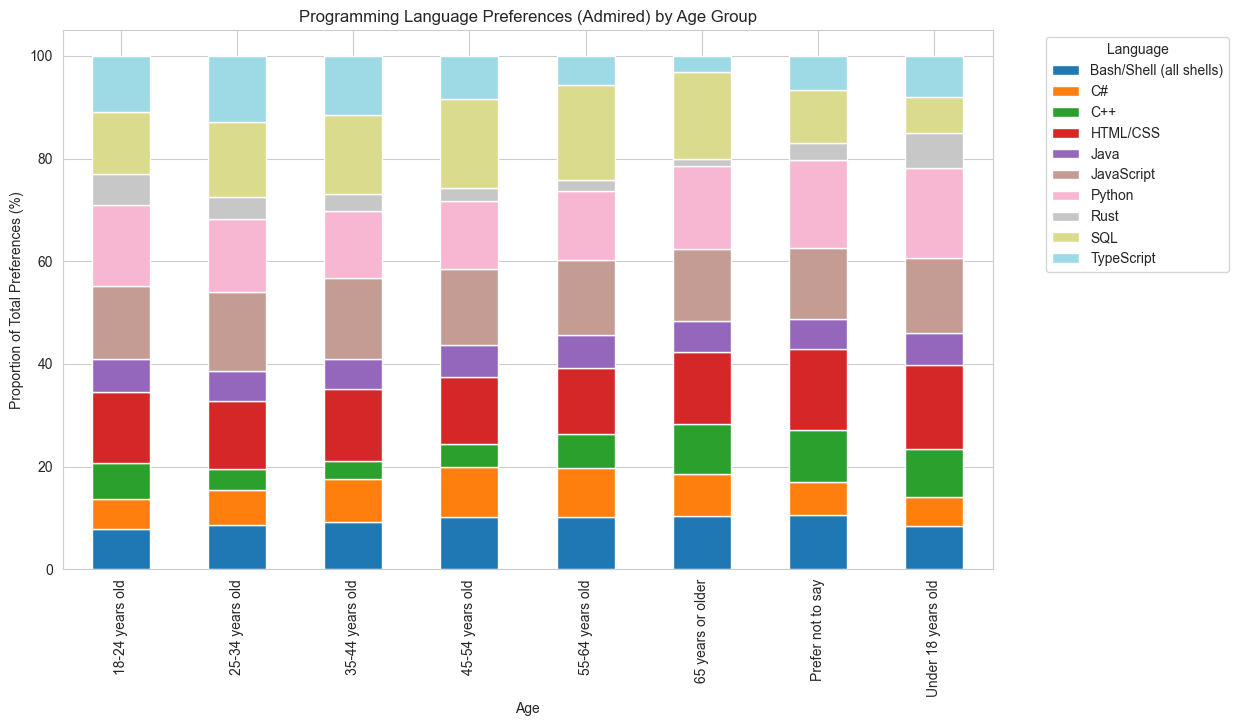

In [47]:
##Write your code here
# 1. Split and Explode
df_admired = df.assign(Language=df['LanguageAdmired'].str.split(';')).explode('Language')

# 2. Filter for top 10 languages (to avoid clutter)
top_langs = df_admired['Language'].value_counts().nlargest(10).index
df_filtered = df_admired[df_admired['Language'].isin(top_langs)].reset_index(drop=True)

# 3 & 4. Create Normalized Crosstab (Proportions)
age_lang_dist = pd.crosstab(df_filtered['Age'], df_filtered['Language'], normalize='index') * 100

# 5. Plot Stacked Bar Chart
age_lang_dist.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Programming Language Preferences (Admired) by Age Group')
plt.ylabel('Proportion of Total Preferences (%)')
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


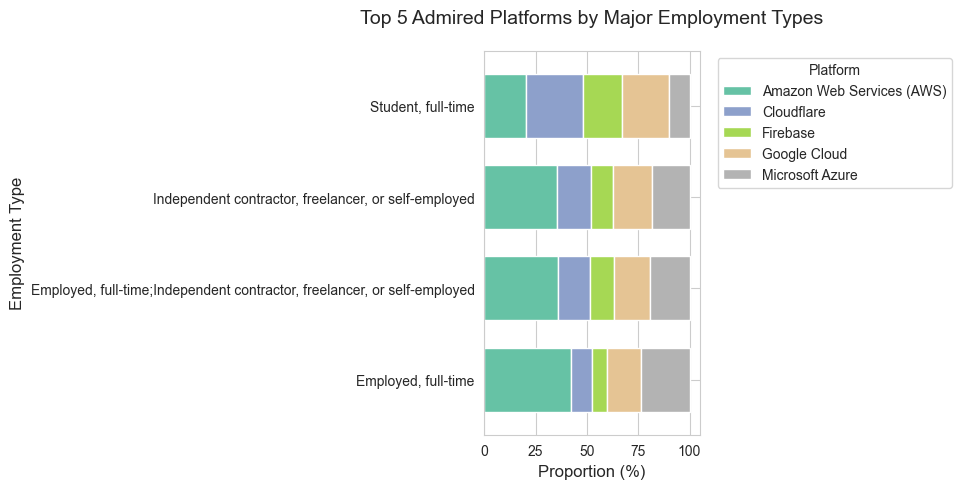

In [21]:
# 1. Clean the original index and explode
df = df.reset_index(drop=True)
df_exp = df.assign(Platform=df['PlatformAdmired'].str.split(';')).explode('Platform')
df_exp['Platform'] = df_exp['Platform'].str.strip()

# 2. REDUCE VARIABLES: Get Top 5 Platforms and Top 4 Employment Types
top_5_platforms = df_exp['Platform'].value_counts().nlargest(5).index
top_4_employment = df_exp['Employment'].value_counts().nlargest(4).index

# 3. Apply filters and reset index to avoid errors
df_clean = df_exp[
    (df_exp['Platform'].isin(top_5_platforms)) &
    (df_exp['Employment'].isin(top_4_employment))
].copy().reset_index(drop=True)

# 4. Create the proportional table (Normalized to 100%)
final_dist = pd.crosstab(df_clean['Employment'], df_clean['Platform'], normalize='index') * 100

# 5. Plot a clean, spaced-out chart
ax = final_dist.plot(kind='barh', stacked=True, figsize=(10, 5), width=0.7, colormap='Set2')

plt.title('Top 5 Admired Platforms by Major Employment Types', fontsize=14, pad=20)
plt.xlabel('Proportion (%)', fontsize=12)
plt.ylabel('Employment Type', fontsize=12)
plt.legend(title='Platform', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # This prevents the labels from being cut off
plt.show()


### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
